Exercício 4

Exercício 5.2

In [1]:
from pathlib import Path
import numpy as np

from si.io.csv_file import read_csv
from si.decomposition.pca import PCA

iris_path = Path(r"C:\Users\filip\OneDrive\Attachments\Ambiente de Trabalho\SIB_gh\si2\datasets\iris\iris.csv")
dataset = read_csv(iris_path, sep=",", features=True, label=True)

dataset.X[:5], dataset.y[:5]


(array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2]]),
 array(['Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
        'Iris-setosa'], dtype=object))

In [2]:
print("Shape original:", dataset.X.shape)
print("Features originais:", dataset.features)


Shape original: (150, 4)
Features originais: Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width'], dtype='object')


In [3]:
pca = PCA(n_components=2)
pca.fit(dataset)
dataset_pca = pca.transform(dataset)

dataset_pca.X[:5]


array([[ 2.68420713,  0.32660731],
       [ 2.71539062, -0.16955685],
       [ 2.88981954, -0.13734561],
       [ 2.7464372 , -0.31112432],
       [ 2.72859298,  0.33392456]])

In [4]:
print("Variância explicada (eigenvalues):")
print(pca.explained_variance_)

ratio = pca.explained_variance_ / pca.explained_variance_.sum()
print("\nRazão de variância explicada:")
print(ratio)

print("\nSoma total da variância explicada:", ratio.sum())


Variância explicada (eigenvalues):
[4.22484077 0.24224357]

Razão de variância explicada:
[0.94577144 0.05422856]

Soma total da variância explicada: 1.0


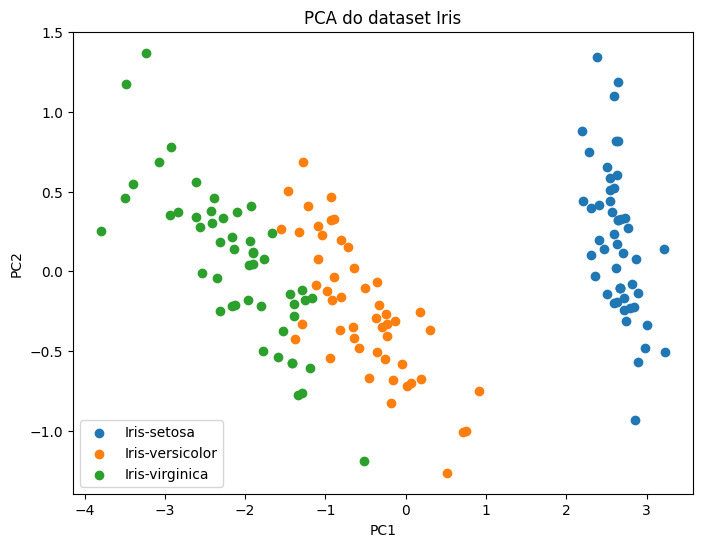

In [5]:
import matplotlib.pyplot as plt

X_pca = dataset_pca.X
labels = dataset.y

plt.figure(figsize=(8,6))
for label in np.unique(labels):
    mask = labels == label
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=label)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA do dataset Iris')
plt.legend()
plt.show()


Exercício 6

In [7]:
from pathlib import Path
import numpy as np

from si.io.csv_file import read_csv
from si.model_selection.split import stratified_train_test_split

iris_path = Path(r"C:\Users\filip\OneDrive\Attachments\Ambiente de Trabalho\SIB_gh\si2\datasets\iris\iris.csv")
dataset = read_csv(iris_path, sep=",", features=True, label=True)

X = dataset.X
y = dataset.y

print("Shape total:", X.shape)
print("Classes:", np.unique(y, return_counts=True))


Shape total: (150, 4)
Classes: (array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object), array([50, 50, 50]))


In [8]:
train_ds, test_ds = stratified_train_test_split(dataset, test_size=0.3, random_state=42)

print("Train shape:", train_ds.X.shape)
print("Test shape:", test_ds.X.shape)

# contar classes
unique, counts_total = np.unique(y, return_counts=True)
unique_train, counts_train = np.unique(train_ds.y, return_counts=True)
unique_test, counts_test = np.unique(test_ds.y, return_counts=True)

print("\nTotal:")
for c, n in zip(unique, counts_total):
    print(f"  {c}: {n}")

print("\nTrain:")
for c, n in zip(unique_train, counts_train):
    print(f"  {c}: {n}")

print("\nTest:")
for c, n in zip(unique_test, counts_test):
    print(f"  {c}: {n}")


Train shape: (105, 4)
Test shape: (45, 4)

Total:
  Iris-setosa: 50
  Iris-versicolor: 50
  Iris-virginica: 50

Train:
  Iris-setosa: 35
  Iris-versicolor: 35
  Iris-virginica: 35

Test:
  Iris-setosa: 15
  Iris-versicolor: 15
  Iris-virginica: 15


In [9]:
print("\nProporções:")
print("Total:", counts_total / counts_total.sum())
print("Train:", counts_train / counts_train.sum())
print("Test:", counts_test / counts_test.sum())



Proporções:
Total: [0.33333333 0.33333333 0.33333333]
Train: [0.33333333 0.33333333 0.33333333]
Test: [0.33333333 0.33333333 0.33333333]


Exercício 7

In [9]:
from pathlib import Path
import numpy as np

from si.io.csv_file import read_csv
from si.model_selection.split import stratified_train_test_split  # ou train_test_split se for regressão pura
from si.models.knn_regressor import KNNRegressor
from si.metrics.rmse import rmse

data_path = Path(r"C:\Users\filip\OneDrive\Attachments\Ambiente de Trabalho\SIB_gh\si2\datasets\cpu\cpu.csv")  # ajusta!
Dataset = read_csv(data_path, sep=",", features=True, label=True)

print("Shape:", dataset.X.shape)
print("Primeiras features:", dataset.features[:5])

from si.model_selection.split import train_test_split  # se existir

train_ds, test_ds = train_test_split(dataset, test_size=0.3, random_state=42)


Shape: (209, 6)
Primeiras features: Index(['syct', 'mmin', 'mmax', 'cach', 'chmin'], dtype='object')


In [10]:
from pathlib import Path
import numpy as np

from si.io.csv_file import read_csv
from si.model_selection.split import stratified_train_test_split  # ou train_test_split se for regressão pura
from si.models.knn_regressor import KNNRegressor
from si.metrics.rmse import rmse

data_path = Path(r"C:\Users\filip\OneDrive\Attachments\Ambiente de Trabalho\SIB_gh\si2\datasets\cpu\cpu.csv")  # ajusta!
Dataset = read_csv(data_path, sep=",", features=True, label=True)

print("Shape:", dataset.X.shape)
print("Primeiras features:", dataset.features[:5])

rng = np.random.default_rng(42)
n = dataset.X.shape[0]
indices = rng.permutation(n)
split = int(0.7 * n)
train_idx, test_idx = indices[:split], indices[split:]

train_ds = Dataset(
    X=dataset.X[train_idx],
    y=dataset.y[train_idx],
    features=dataset.features,
    label=dataset.label,
)
test_ds = Dataset(
    X=dataset.X[test_idx],
    y=dataset.y[test_idx],
    features=dataset.features,
    label=dataset.label,
)


Shape: (209, 6)
Primeiras features: Index(['syct', 'mmin', 'mmax', 'cach', 'chmin'], dtype='object')


TypeError: 'Dataset' object is not callable

In [8]:
model = KNNRegressor(k=5)
model.fit(train_ds)

y_train_pred = model.predict(train_ds)
y_test_pred = model.predict(test_ds)

rmse_train = rmse(train_ds.y, y_train_pred)
rmse_test = rmse(test_ds.y, y_test_pred)

print("RMSE (train):", rmse_train)
print("RMSE (test):", rmse_test)


RMSE (train): 44.88600224211231
RMSE (test): 151.41521634873914
